# 03 — Modeling (Baselines)

# Predicting Gallstone Disease from Clinical + Bioimpedance

**Domain:** Healthcare | **Task:** Binary Classification | **Data:** Tabular  
**Dataset:** `data/dataset-uci.csv`  
**Target column:** `Gallstone Status` (Yes[1]/No[0])

Run the cells top-to-bottom. These notebooks avoid seaborn per instructions and use pure matplotlib for charts.

## Objectives
- Establish baselines with Logistic Regression, Decision Tree, Random Forest
- Use validation set for model selection
- Record metrics: Accuracy, Precision, Recall, F1, ROC-AUC

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, roc_curve
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB


# Load processed data
X_train = np.load("../data/processed/X_train_scaled.npy")
X_valid = np.load("../data/processed/X_valid_scaled.npy")
y_train = np.load("../data/processed/y_train.npy")
y_valid = np.load("../data/processed/y_valid.npy")
feature_names = pd.read_csv("../data/processed/feature_names.csv", header=None)[0].tolist()

models = {
    "LogisticRegression": LogisticRegression(max_iter=1000, random_state=42),
    "DecisionTree": DecisionTreeClassifier(random_state=42),
    "RandomForest": RandomForestClassifier(n_estimators=300, random_state=42),
    "KNeighbors": KNeighborsClassifier(n_neighbors=5),
    "SVC": SVC(probability=True, random_state=42),
    "GaussianNB": GaussianNB(),
}

results = []

for name, clf in models.items():
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_valid)
    # handle predict_proba if available
    if hasattr(clf, "predict_proba"):
        y_prob = clf.predict_proba(X_valid)[:,1]
    else:
        # fallback to decision_function or zeros
        if hasattr(clf, "decision_function"):
            from sklearn.preprocessing import MinMaxScaler
            scores = clf.decision_function(X_valid).reshape(-1,1)
            y_prob = MinMaxScaler().fit_transform(scores).ravel()
        else:
            y_prob = np.zeros_like(y_pred, dtype=float)

    metrics = dict(
        model=name,
        accuracy=accuracy_score(y_valid, y_pred),
        precision=precision_score(y_valid, y_pred),
        recall=recall_score(y_valid, y_pred),
        f1=f1_score(y_valid, y_pred),
        roc_auc=roc_auc_score(y_valid, y_prob) if len(np.unique(y_valid))>1 else np.nan
    )
    results.append(metrics)

res_df = pd.DataFrame(results).sort_values("roc_auc", ascending=False)
res_df

,model,accuracy,precision,recall,f1,roc_auc
2,RandomForest,0.812500,0.826087,0.791667,0.808511,0.866319
0,LogisticRegression,0.750000,0.750000,0.750000,0.750000,0.862847
4,SVC,0.687500,0.714286,0.625000,0.666667,0.826389
1,DecisionTree,0.770833,0.760000,0.791667,0.775510,0.770833
5,GaussianNB,0.583333,1.000000,0.166667,0.285714,0.711806
3,KNeighbors,0.687500,0.714286,0.625000,0.666667,0.703993


## Plot ROC curves for the baselines

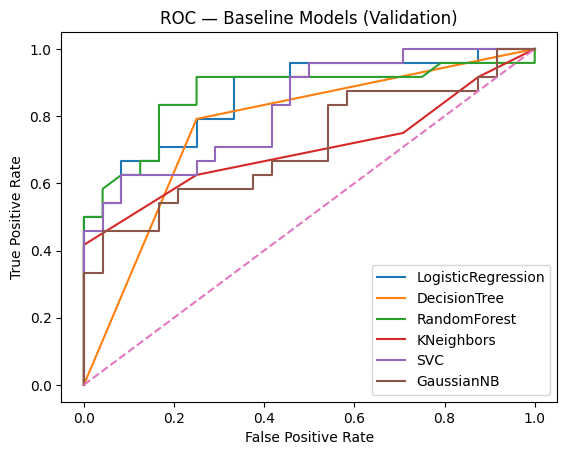

In [9]:
plt.figure()
for name in models.keys():
    # Refit to ensure we have the trained instance here (for clarity)
    match name:
        case "LogisticRegression":
            clf = LogisticRegression(max_iter=1000, random_state=42)
        case "DecisionTree":
            clf = DecisionTreeClassifier(random_state=42)
        case "RandomForest":
            clf = RandomForestClassifier(n_estimators=300, random_state=42)
        case "KNeighbors":
            clf = KNeighborsClassifier(n_neighbors=5)
        case "SVC":
            clf = SVC(probability=True, random_state=42)
        case "GaussianNB":
            clf = GaussianNB()
        case _:
            raise ValueError(f"Unknown model name: {name}")

    clf.fit(X_train, y_train)
    if hasattr(clf, "predict_proba"):
        y_prob = clf.predict_proba(X_valid)[:,1]
        fpr, tpr, _ = roc_curve(y_valid, y_prob)
        plt.plot(fpr, tpr, label=name)
    elif hasattr(clf, "decision_function"):
        scores = clf.decision_function(X_valid)
        # normalize to [0,1] to plot ROC
        s = (scores - scores.min())/(scores.max()-scores.min()+1e-9)
        fpr, tpr, _ = roc_curve(y_valid, s)
        plt.plot(fpr, tpr, label=name)

plt.plot([0,1],[0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC — Baseline Models (Validation)")
plt.legend()
plt.show()

## Confusion matrix of the best baseline (by ROC-AUC)

Best baseline: RandomForest


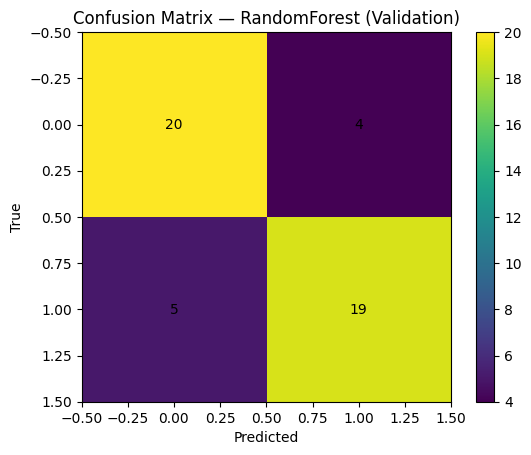

,model,accuracy,precision,recall,f1,roc_auc
2,RandomForest,0.812500,0.826087,0.791667,0.808511,0.866319
0,LogisticRegression,0.750000,0.750000,0.750000,0.750000,0.862847
4,SVC,0.687500,0.714286,0.625000,0.666667,0.826389
1,DecisionTree,0.770833,0.760000,0.791667,0.775510,0.770833
5,GaussianNB,0.583333,1.000000,0.166667,0.285714,0.711806
3,KNeighbors,0.687500,0.714286,0.625000,0.666667,0.703993


In [8]:
best_name = res_df.iloc[0]["model"]
print("Best baseline:", best_name)

# Train & evaluate on validation
if best_name == "LogisticRegression":
    best = LogisticRegression(max_iter=200, random_state=42)
elif best_name == "DecisionTree":
    best = DecisionTreeClassifier(random_state=42)
else:
    best = RandomForestClassifier(n_estimators=300, random_state=42)

best.fit(X_train, y_train)
y_pred = best.predict(X_valid)
cm = confusion_matrix(y_valid, y_pred)

plt.figure()
plt.imshow(cm)
plt.title(f"Confusion Matrix — {best_name} (Validation)")
plt.xlabel("Predicted")
plt.ylabel("True")
for (i,j), v in np.ndenumerate(cm):
    plt.text(j, i, str(v), ha='center', va='center')
plt.colorbar()
plt.show()

res_df